# DL Lab AutoML: Nano-TabPFN
In this exercise we will learn about [TabPFN](https://www.nature.com/articles/s41586-024-08328-6.pdf), a foundation model for tabular data. We will use Nano-TabPFN, a simplified version of TabPFN, to introduce the architecture, training code, and synthetic data generation using a prior.

Before you start, make sure you have installed the following dependencies:
- PyTorch (`pip install torch==2.6.0`)
- PFNs (`pip install pfns==0.3.0`)
- TabPFN (`pip install tabpfn==2.0.9`)

We used `python=3.11.13` to develop this notebook, so it's best if you do too.

---

**HOW THIS EXERCISE WORKS — please read carefully.**

Unlike a normal "fill-in-the-blanks" exercise, this notebook contains **two kinds of issues** you need to find and fix:

1. **TODOs (completions).** Marked clearly with `# ----- TODO ... -----` and `raise NotImplementedError`. Just like before — read the docstring and the surrounding code, then write the missing line(s).

2. **Hidden semantic bugs.** Some lines look complete and run without raising, but they are **wrong** — they do something different from what the function's docstring/comments promise. There are exactly:
     - **4 hidden bugs in the model / training code**.
     - **3 hidden bugs in the MLP-prior code**.
   Bugs are not localized. They are *subtle*. The only way to find them is to **read each docstring carefully** and compare it to the actual implementation.

   Examples of subtle bugs can be data leakage, incorrect sampling, etc..

To complete the exercise, fill all the TODOs **and** find and fix the 7 bugs. When you fix a bug, leave a short comment on the line you changed describing what was wrong. After doing so, run all the cells, save the notebook and upload only the .ipynb file. Do not upload anything else!

Please put a cell at the bottom of this noteboook, describing the way you used LLMs in order to solve this exercise.

TabPFN works in a very different way compared to conventional tabular models like XGBoost, RandomForest, etc.
Given a training dataset `X_train`, `y_train` and the features `X_test` of a datapoint that we want to predict, a conventional model would first learn its parameters by being trained/fit on `X_train`, `y_train` and then in a second phase would perform inference on `X_test`.
TabPFN instead performs fitting and inference in a single forward pass by doing in-context learning.
It's very similar to how an LLM works, but instead of embedding text tokens, we embed cells in a table. The "prompt" consists of `X_train`, `y_train`, `X_test` and the output will be our predictions for the labels of `X_test`. TabPFN is trained on millions of synthetic datasets sampled from a prior.

In this exercise we will first introduce the idea of a data generating prior by implementing a very simple prior that generates data that correspond to linear functions. Then we will build a simple version of TabPFN's architecture and training loop and train it on the linear prior.
Afterwards we will replace the linear prior with a richer **MLP-based structural causal model (SCM) prior** and use it to train a small classification model. Finally we compare against TabPFNv2 and other tabular baselines.

## 1. Linear Prior

TabPFN is trained on synthetic datasets sampled from a prior. For this exercise it is sufficient to just think of a prior as code that generates batches of data from a distribution. If you are interested you can read up more about prior-fitted networks [here](https://arxiv.org/pdf/2112.10510). A prior for tabular data needs to generate datasets that look like tables. The actual prior used for TabPFN is quite complex; we will look at it later. For now, let's start with a prior for linear functions. Linear functions are defined by their slope $m$ and y-intercept $c$. It is normally assumed that observations $y$ contain noise $\epsilon$ which we will also add to our prior.

$$ y = f(x)+ \epsilon, \qquad f(x)= m\cdot x+c \qquad, \text{with} \ \epsilon \sim N(0,\sigma^2).$$

For our prior, we first sample linear functions by sampling their slope and y-intercept from a normal distribution. Afterwards, we generate random `x` values, pass them through the function (i.e., multiplying with the slope and adding the y-intercept), and add some noise to get our labels `y`.

We define a `get_batch` function which returns feature values `x`, corresponding labels `y`, and `single_eval_pos`, the index at which the data in the batch is split into train and test set. `X_train` and `y_train` will be the first `single_eval_pos` rows in `x` and `y` respectively.

In [1]:
from torch.utils.data import DataLoader
import random
import torch

@torch.no_grad()
def get_batch_linear(batch_size=2, seq_len=100, num_features=1, device='cpu', label_std=0.1, weight_std=1.):
    # a linear function looks like y=mx+c, if we use w to store all constants we can
    # rewrite it to y=w[0]*x+w[1], this is why we have num_features=1 in the line below
    weights = torch.distributions.Normal(torch.zeros(num_features+1), weight_std).sample((batch_size,))
    # print(weights)
    # print("-----------------")
    x = torch.rand(batch_size, seq_len, num_features)
    # we extend x with 1, so that we can write y=w[0]*x[0]+w[1]*x[1]
    # print(x.shape)
    x = torch.cat([x,torch.ones(batch_size, seq_len, 1)], 2)
    # print(x.shape)
    # ----- TODO -----
    # raise NotImplementedError
    
    # Calculate y, considering that c and m are now subsumed into `weights`. Don't forget the noise using `label_std`.
    # ----------------
    # Remove the concatenated 1 from x
    y = (x * weights.unsqueeze(1)).sum(-1) + torch.randn(batch_size, seq_len) * label_std
    # print(y.shape)
    x = x[:,:,:num_features]
    # we would like to always have at least 2 data points in training and 1 in test
    single_eval_pos = random.choices(range(2, seq_len-1))[0]
    # transformer expects (sequence, batch, features) so we transpose
    return dict(x=x.transpose(0, 1).to(device), y=y.transpose(0, 1).to(device), single_eval_pos=single_eval_pos)


In [2]:
get_batch_linear()

{'x': tensor([[[0.4381],
          [0.5548]],
 
         [[0.4913],
          [0.1318]],
 
         [[0.9475],
          [0.6309]],
 
         [[0.5163],
          [0.6153]],
 
         [[0.1257],
          [0.3376]],
 
         [[0.0268],
          [0.0545]],
 
         [[0.0736],
          [0.2590]],
 
         [[0.8383],
          [0.8925]],
 
         [[0.0309],
          [0.0966]],
 
         [[0.8474],
          [0.8330]],
 
         [[0.6247],
          [0.0598]],
 
         [[0.1033],
          [0.5091]],
 
         [[0.9452],
          [0.1542]],
 
         [[0.7232],
          [0.2591]],
 
         [[0.0391],
          [0.6232]],
 
         [[0.4819],
          [0.9584]],
 
         [[0.8718],
          [0.0579]],
 
         [[0.7925],
          [0.1926]],
 
         [[0.1434],
          [0.9248]],
 
         [[0.7006],
          [0.7098]],
 
         [[0.6572],
          [0.8754]],
 
         [[0.3521],
          [0.7855]],
 
         [[0.9512],
          [0.5203]],
 
      

Let's visualize some datasets to make sure we have done everything correctly:

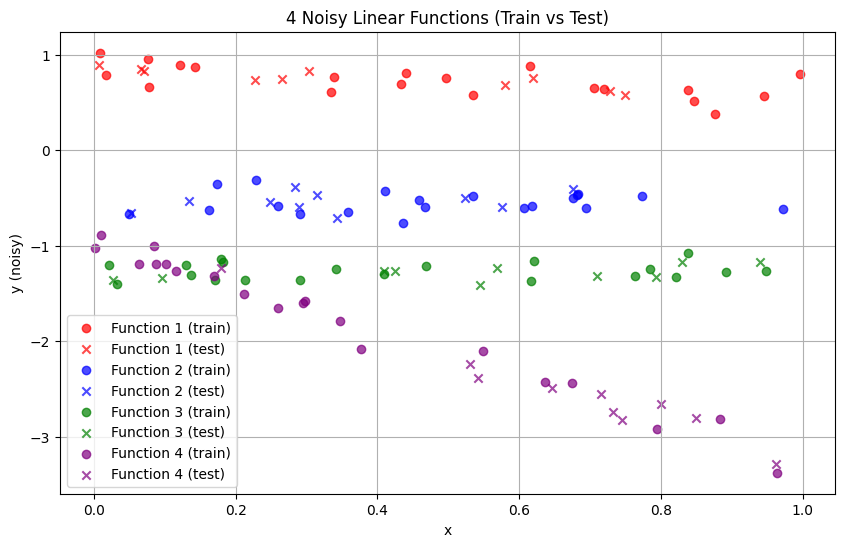

In [3]:
import matplotlib.pyplot as plt
from utils import set_randomness_seed

set_randomness_seed(2402)

batch = get_batch_linear(batch_size=4, seq_len=30)
x = batch['x'].cpu()  # [seq_len, batch_size, num_features]
y = batch['y'].cpu()  # [seq_len, batch_size]
split_idx = batch['single_eval_pos']

seq_len, batch_size, num_features = x.shape
colors = ['red', 'blue', 'green', 'purple']

plt.figure(figsize=(10, 6))
for i in range(batch_size):
    xi = x[:, i, 0]
    yi = y[:, i]
    plt.scatter(xi[:split_idx], yi[:split_idx], color=colors[i], marker='o',
                label=f'Function {i+1} (train)', alpha=0.7)
    plt.scatter(xi[split_idx:], yi[split_idx:], color=colors[i], marker='x',
                label=f'Function {i+1} (test)', alpha=0.7)
plt.xlabel('x'); plt.ylabel('y (noisy)')
plt.title('4 Noisy Linear Functions (Train vs Test)')
plt.legend(); plt.grid(True); plt.show()


We would like to work with a dataloader in our training loop, so we define a class that converts our `get_batch` function to a PyTorch-compatible DataLoader:

In [4]:
from typing import Callable, Iterator, Dict, Union
class PriorDataLoader(DataLoader):
    def __init__(self, get_batch_function: Callable[..., Dict[str, Union[torch.Tensor, int]]],
                 num_steps: int, batch_size: int, num_datapoints_max: int,
                 num_features: int, device: torch.device):
        self.get_batch_function = get_batch_function
        self.num_steps = num_steps
        self.batch_size = batch_size
        self.num_datapoints_max = num_datapoints_max
        self.num_features = num_features
        self.device = device

    def __iter__(self) -> Iterator[Dict[str, Union[torch.Tensor, int]]]:
        return iter(self.get_batch_function(self.batch_size, self.num_datapoints_max, self.num_features)
                    for _ in range(self.num_steps))

    def __len__(self) -> int:
        return self.num_steps


Now that we have our data generating code, let's look at TabPFN's architecture next.
We are only using a single feature in our linear example, but tabular datasets usually have many features, so keep that in mind when looking at the next part.

## 2. Architecture

![Overview of TabPFN Architecture](https://ml.informatik.uni-freiburg.de/research-artifacts/dl-lab-2025/figures/architecture.png)

On a very abstract level, TabPFN works by alternatingly applying attention between features and attention between datapoints on the Table as illustrated above. In order to do this, we first have to create an embedding for each cell in the Table. We create the embeddings for all the features (`X_train` and `X_test`!) using the so-called FeatureEncoder. All the Feature Encoder does is normalize the data inside each column, based on the mean and standard deviation of the **training set** of the respective column, clip it if the features become too large/small, and then apply a linear layer.

In [5]:
# BUG here! Catch me if you can!
from torch import nn

class FeatureEncoder(nn.Module):
    def __init__(self, embedding_size: int):
        """ Creates the linear layer that we will use to embed our features. """
        super().__init__()
        self.linear_layer = nn.Linear(1, embedding_size)

    def forward(self, x: torch.Tensor, single_eval_pos: int) -> torch.Tensor:
        """
        Normalizes each features based on the mean and std of the respective features training split,
        clips them between -100 and 100, then applies a linear layer to embed the features.

        Using only the training rows for the mean/std is essential: using the test rows
        too would leak test information into the normalization and is a form of data leakage.

        Args:
            x: (torch.Tensor) a tensor of shape (num_rows, batch_size, num_features)
            single_eval_pos: (int) the number of datapoints in X_train
        Returns:
            (torch.Tensor) a tensor of shape (num_rows, batch_size, num_features, embedding_size)
        """
        x = x.unsqueeze(-1)
        # print(x.shape)
        mean = torch.mean(x[:single_eval_pos], dim=0, keepdim=True)  # bug was using all rows instead of just training rows
        std = torch.std(x[:single_eval_pos], dim=0, keepdim=True) + 1e-20
        x = (x - mean) / std
        x = torch.clip(x, min=-100, max=100)
        return self.linear_layer(x)


We also need embeddings for the target column. We extend `y_train` with its mean values so that we have cells for `y_test` too. Afterwards we apply a linear layer again like in the FeatureEncoder.

In [6]:
#Don't make mistakes, like the BUG in here!
class TargetEncoder(nn.Module):
    def __init__(self, embedding_size: int):
        """ Creates the linear layer that we will use to embed our targets. """
        super().__init__()
        self.linear_layer = nn.Linear(1, embedding_size)

    def forward(self, y_train: torch.Tensor, num_rows: int) -> torch.Tensor:
        """
        Pads `y_train` to the full length `num_rows` using the per-dataset mean
        of `y_train`, and then embeds the result using a linear layer.

        Critically, the datasets inside one batch can have different means, so the
        padding must be computed per column of the batch. Using a single scalar mean
        across the whole batch loses that per-dataset information.

        Args:
            y_train: (torch.Tensor) a tensor of shape (num_train_rows, batch_size, 1)
            num_rows: (int) the full length of y
        Returns:
            (torch.Tensor) a tensor of shape (num_rows, batch_size, 1, embedding_size)
        """
        # print(y_train.shape)
        mean = torch.mean(y_train, dim=0, keepdim=True) # was calculating global mean
        # print(mean)
        padding = mean.repeat(num_rows - y_train.shape[0], 1, 1)
        # print(padding.shape)
        y = torch.cat([y_train, padding])
        # print(y.shape)
        y = y.unsqueeze(-1)
        return self.linear_layer(y)


Now that we have embeddings for all the cells in the table, we can build our transformer block that will work on these embeddings.
Our Transformer block will look quite a bit different from a normal one, since we don't have a simple 1D sequence on which we want to do our attention, but instead we have a 2D Table on which we want to do attention between features and attention between datapoints alternatingly. When it comes to the attention between datapoints, we will modify our attention mechanism so that:

- **training tokens may only attend to other training tokens** (never to test tokens),
- **test tokens may only attend to training tokens** (and not to each other).

We do this so that adding or removing a test datapoint doesn't change the predictions of any other test datapoint, because the test tokens never see each other. 

Since we want permutation-equivariance we also do not use a positional embeddings here either.

![Architecture of Transformer Block](https://ml.informatik.uni-freiburg.de/research-artifacts/dl-lab-2025/figures/transformer_layer.png)


MultiheadAttention works on `(sequence_length, batch_dim, embedding_size)` tensors; ours look like `(num_rows, batch_dim, num_columns, embedding_size)`. We have to transpose so the dimension we want to attend along is in front, and reshape so the other table dimension gets folded into the batch dimension. After applying attention between datapoints and attention between features we finish our transformer block with a simple MLP. We have skip connections around both MultiheadAttention blocks and the MLP, and apply a LayerNorm after all of these skip connections.

In [7]:
# Watch out! Danger! BUG ahead!
from torch.nn.modules.transformer import MultiheadAttention, Linear, LayerNorm

class TransformerEncoderLayer(nn.Module):
    """ Modified version of older version of https://github.com/pytorch/pytorch/blob/v2.6.0/torch/nn/modules/transformer.py#L630 """
    def __init__(self, embedding_size: int, nhead: int, mlp_hidden_size: int,
                 layer_norm_eps: float = 1e-5, batch_first: bool = False,
                 device=None, dtype=None):
        super().__init__()
        self.self_attn_between_datapoints = MultiheadAttention(embedding_size, nhead, batch_first=batch_first, device=device, dtype=dtype)
        self.self_attn_between_features = MultiheadAttention(embedding_size, nhead, batch_first=batch_first, device=device, dtype=dtype)
        self.linear1 = Linear(embedding_size, mlp_hidden_size, device=device, dtype=dtype)
        self.linear2 = Linear(mlp_hidden_size, embedding_size, device=device, dtype=dtype)
        self.norm1 = LayerNorm(embedding_size, eps=layer_norm_eps, device=device, dtype=dtype)
        self.norm2 = LayerNorm(embedding_size, eps=layer_norm_eps, device=device, dtype=dtype)
        self.norm3 = LayerNorm(embedding_size, eps=layer_norm_eps, device=device, dtype=dtype)

    def forward(self, src: torch.Tensor, single_eval_position: int) -> torch.Tensor:
        """
        Takes the embeddings of the table as input and applies self-attention between features
        and self-attention between datapoints, followed by a simple 2-layer MLP.

        Regarding the row attention:
            - The training rows (the first `single_eval_position` rows) attend only to
              other training rows.
            - The test rows attend ONLY to the training rows (never to each other).
        Together this guarantees that adding or removing a test datapoint doesn't change
        the predictions for any other test datapoint, and that the training rows can never
        leak information from the test rows.

        Args:
            src: (torch.Tensor) shape (num_rows, batch_size, num_columns, embedding_size)
            single_eval_position: (int) the length of X_train
        Returns:
            (torch.Tensor) shape (num_rows, batch_size, num_features, embedding_size)
        """
        rows_size, batch_size, col_size, embedding_size = src.shape

        # attention between features
        src = src.transpose(0, 2)
        src = src.reshape(col_size, batch_size * rows_size, embedding_size)
        src = self.self_attn_between_features(src, src, src)[0] + src
        src = src.reshape(col_size, batch_size, rows_size, embedding_size)
        src = src.transpose(0, 2)
        src = self.norm1(src)
        # print(src)

        # attention between datapoints
        src = src.reshape(rows_size, batch_size * col_size, embedding_size)
        # training data attends to itself only
        src_left = self.self_attn_between_datapoints(
            src[:single_eval_position], src[:single_eval_position], src[:single_eval_position]
        )[0]
        # ----- TODO -----
        # Test data should attend ONLY to training data: queries are the test rows,
        # keys/values are the training rows.
        # raise NotImplementedError
        src_right = self.self_attn_between_datapoints(
            src[single_eval_position:], src[:single_eval_position], src[:single_eval_position]
        )[0]    # was attending to all rows
        # print(src_right)
        # ----------------
        src = torch.cat([src_left, src_right], dim=0) + src
        src = src.reshape(rows_size, batch_size, col_size, embedding_size)
        src = self.norm2(src)

        # MLP after attention
        src = self.linear2(F.gelu(self.linear1(src))) + src
        src = self.norm3(src)
        return src


We use multiple of these Transformer Blocks, so we create a `TransformerEncoderStack`, which contains `num_layers` many `TransformerEncoderLayer`s and applies them sequentially.

In [8]:
class TransformerEncoderStack(nn.Module):
    def __init__(self, num_layers: int, embedding_size: int, num_attention_heads: int, mlp_hidden_size: int):
        """ Instantiates `num_layers` many Transformer Blocks and stores them in a list. """
        super().__init__()
        self.transformer_blocks = nn.ModuleList()
        for _ in range(num_layers):
            self.transformer_blocks.append(TransformerEncoderLayer(embedding_size, num_attention_heads, mlp_hidden_size))

    def forward(self, x: torch.Tensor, single_eval_position: int) -> torch.Tensor:
        """
        Args:
            x: (torch.Tensor) shape (num_rows, batch_size, num_columns, embedding_size)
            single_eval_position: (int) the length of X_train
        Returns:
            (torch.Tensor) shape (num_rows, batch_size, num_features, embedding_size)
        """
        for block in self.transformer_blocks:
            x = block(x, single_eval_position=single_eval_position)
        return x


The last part of our architecture is the decoder, it will take the embeddings of the `y_test` cells as input and apply a 2-layer MLP that will output the predicted logits for all rows and classes if we have a classification task.
If we have a regression task, it will actually also output the predictions for the classes! This might sound weird, but if you use `TabPFNRegressor`, it will actually convert the regression problem into classification by creating thousands of buckets, discretizing the continuous space of target values. All of this complexity is hidden in `FullSupportBarDistribution`, the loss criterion we will use later. We will not cover how this works in this exercise; it's sufficient for you to think of this as something that turns Regression Problems into Classification Problems.

In [9]:
class Decoder(nn.Module):
    def __init__(self, embedding_size: int, mlp_hidden_size: int, num_outputs: int):
        """ Initializes the linear layers for use in the forward """
        super().__init__()
        self.linear1 = nn.Linear(embedding_size, mlp_hidden_size)
        self.linear2 = nn.Linear(mlp_hidden_size, num_outputs)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Applies an MLP to the embeddings to get the logits.
        Args:
            x: (torch.Tensor) shape (num_rows, batch_size, embedding_size)
        Returns:
            (torch.Tensor) shape (num_rows, batch_size, num_outputs)
        """
        return self.linear2(F.gelu(self.linear1(x)))


Now we have all pieces ready: the `FeatureEncoder`, the `TargetEncoder`, the `TransformerEncoderStack` and the `Decoder`. Let's wire them up into our `NanoTabPFNModel`.

The `NanoTabPFNModel` encodes features with the `FeatureEncoder` and labels with the `TargetEncoder`, concatenates them along the column axis to form a table of embeddings called `src`, runs `src` through the `TransformerEncoderStack`, picks the embeddings corresponding to `y_test`, and feeds them through the `Decoder` to get the logits.

We offer two interfaces to the `forward` function: either pass `X_train, y_train, X_test` separately (sklearn-style), or pass the already-concatenated `(x, y_train), single_eval_pos`. Internally we always work with the latter.

In [10]:
import torch
from torch import nn
import torch.nn.functional as F
from typing import Tuple, Union

class NanoTabPFNModel(nn.Module):
    def __init__(self, embedding_size: int, num_attention_heads: int,
                 mlp_hidden_size: int, num_layers: int, num_outputs: int):
        """ Initializes the feature/target encoder, transformer stack and decoder. """
        super().__init__()
        self.num_outputs = num_outputs
        # ----- TODO -----
        # raise NotImplementedError
        self.feature_encoder = FeatureEncoder(embedding_size)
        self.target_encoder = TargetEncoder(embedding_size)
        self.transformer_encoder = TransformerEncoderStack(num_layers, embedding_size, num_attention_heads, mlp_hidden_size)
        self.decoder = Decoder(embedding_size, mlp_hidden_size, num_outputs)
        # ----------------

    def forward(self, *args, **kwargs) -> torch.Tensor:
        """
        Two interfaces:
            model(X_train, y_train, X_test)
            model((x, y_train), single_eval_pos=...)
        """
        if len(args) == 3:
            x = args[0]
            if args[2] is not None:
                x = torch.cat((x, args[2]), dim=0)
            return self._forward((x, args[1]), single_eval_pos=len(args[0]), **kwargs)
        elif len(args) == 1 and isinstance(args, tuple):
            return self._forward(*args, **kwargs)

    def _forward(self, src: Tuple[torch.Tensor, torch.Tensor], single_eval_pos: int) -> torch.Tensor:
        x_src, y_src = src
        if len(y_src.shape) < len(x_src.shape):
            y_src = y_src.unsqueeze(-1)
        # R=Rows, B=Batches, C=Columns, E=embedding size
        x_src = self.feature_encoder(x_src, single_eval_pos)
        num_rows = x_src.shape[0]
        y_src = self.target_encoder(y_src, num_rows)
        src = torch.cat([x_src, y_src], 2)                     # (R,B,C,E)
        output = self.transformer_encoder(src, single_eval_pos)
        output = output[single_eval_pos:, :, -1, :]            # take y_test embeddings
        output = self.decoder(output)                          # logits
        return output


## 3. Training Loop

Now that we have the architecture and the prior, we just need to create our training loop to pretrain TabPFN.

In [11]:
# Oh god, another BUG hid somewhere here, but this one is easy.
import torch
from torch import nn
import time
import schedulefree
from utils import get_default_device
from pfns.bar_distribution import FullSupportBarDistribution

def train(model: NanoTabPFNModel, prior, criterion, epochs: int,
          lr: float = 4e-3, device: torch.device = None,
          steps_per_log: int = 20, verbose: bool = True):
    """
    Trains our model on the given prior using the given criterion.
    Uses schedulefree.AdamWScheduleFree, prints loss every `steps_per_log` steps so
    progress is visible inside an epoch (otherwise you'd only see one line per epoch).
    """
    if not device:
        device = get_default_device()
    model.to(device)
    optimizer = schedulefree.AdamWScheduleFree(model.parameters(), lr=lr, weight_decay=0.0)
    classification_task = isinstance(criterion, nn.CrossEntropyLoss)

    model.train(); optimizer.train()
    global_step = 0
    train_time = 0.0
    try:
        for epoch in range(1, epochs + 1):
            epoch_start = time.time()
            running = 0.0
            running_n = 0
            for step, full_data in enumerate(prior):
                step_start = time.time()
                single_eval_pos = full_data['single_eval_pos']
                nan_x = torch.isnan(full_data["x"]).any()
                nan_y = torch.isnan(full_data["y"]).any()
                if nan_x or nan_y:
                    src = "x" if nan_x and not nan_y else "y" if nan_y and not nan_x else "x and y"
                    print(f"NaN detected in {src} at step {step}!")
                    print(f"  x: {full_data['x']}")
                    print(f"  y: {full_data['y']}")
                    continue
                data = (full_data['x'].to(device), full_data['y'][:single_eval_pos].to(device))
                targets = full_data['y'][single_eval_pos:].to(device)

                output = model(data, single_eval_pos=single_eval_pos)
                if classification_task:
                    targets = targets.reshape((-1,)).to(torch.long)
                    output = output.view(len(targets), -1)
                loss = criterion(output, targets).mean()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.)
                loss.backward() #no backward pass was being done

                optimizer.step()
                optimizer.zero_grad()

                running += loss.cpu().detach().item()
                running_n += 1
                global_step += 1
                train_time += time.time() - step_start

                if verbose and global_step % steps_per_log == 0:
                    print(
                        f"step {global_step:5d} | epoch {epoch:3d} | "
                        f"time {train_time:7.1f}s | "
                        f"loss(last {running_n}) {running/running_n:7.4f}",
                        flush=True,
                    )
                    running = 0.0
                    running_n = 0

            if verbose:
                print(
                    f"--- end of epoch {epoch:3d} | epoch time: "
                    f"{time.time() - epoch_start:5.1f}s ---",
                    flush=True,
                )
    except KeyboardInterrupt:
        pass
    optimizer.eval()
    model.eval()
    return model, (running / running_n if running_n else float("nan"))

Finally we will run the training. You may change `batch_size`/`num_steps`/`epochs` if you run out of memory or the training takes too long.

In [12]:
from utils import get_default_device, get_openai_lr
from pfns import bar_distribution
import warnings

set_randomness_seed(2402)

device = get_default_device()
num_features = 1
prior = PriorDataLoader(get_batch_function=get_batch_linear, num_steps=50, batch_size=32,
                        num_datapoints_max=30, num_features=num_features, device=device)

warnings.filterwarnings("ignore")
ys = get_batch_linear(100000, 20, num_features)['y'].to(device)
criterion = bar_distribution.FullSupportBarDistribution(
    bar_distribution.get_bucket_limits(num_outputs=100, ys=ys))

model = NanoTabPFNModel(num_attention_heads=4, embedding_size=256,
                        mlp_hidden_size=512, num_layers=4, num_outputs=criterion.num_bars)

trained_model, loss = train(model=model, prior=prior, criterion=criterion, epochs=10, device=device,
                            lr=get_openai_lr(model))


Using 2000000 y evals to estimate 100 buckets. Cut off the last 0 ys.
step    20 | epoch   1 | time     3.6s | loss(last 20)  0.9733
step    40 | epoch   1 | time     6.0s | loss(last 20)  0.2490
--- end of epoch   1 | epoch time:   7.1s ---
step    60 | epoch   2 | time     8.0s | loss(last 10)  0.0157
step    80 | epoch   2 | time    10.0s | loss(last 20) -0.2183
step   100 | epoch   2 | time    12.2s | loss(last 20) -0.1764
--- end of epoch   2 | epoch time:   5.0s ---
step   120 | epoch   3 | time    13.9s | loss(last 20) -0.3216
step   140 | epoch   3 | time    15.7s | loss(last 20) -0.2815
--- end of epoch   3 | epoch time:   4.3s ---
step   160 | epoch   4 | time    17.2s | loss(last 10) -0.3128
step   180 | epoch   4 | time    18.8s | loss(last 20) -0.4080
step   200 | epoch   4 | time    20.4s | loss(last 20) -0.4239
--- end of epoch   4 | epoch time:   4.0s ---
step   220 | epoch   5 | time    21.9s | loss(last 20) -0.3543
step   240 | epoch   5 | time    23.5s | loss(last 20

Now we have a Nano-TabPFN trained on a bunch of linear problems; let's sample a new linear problem and compare its predictions to Ridge regression.

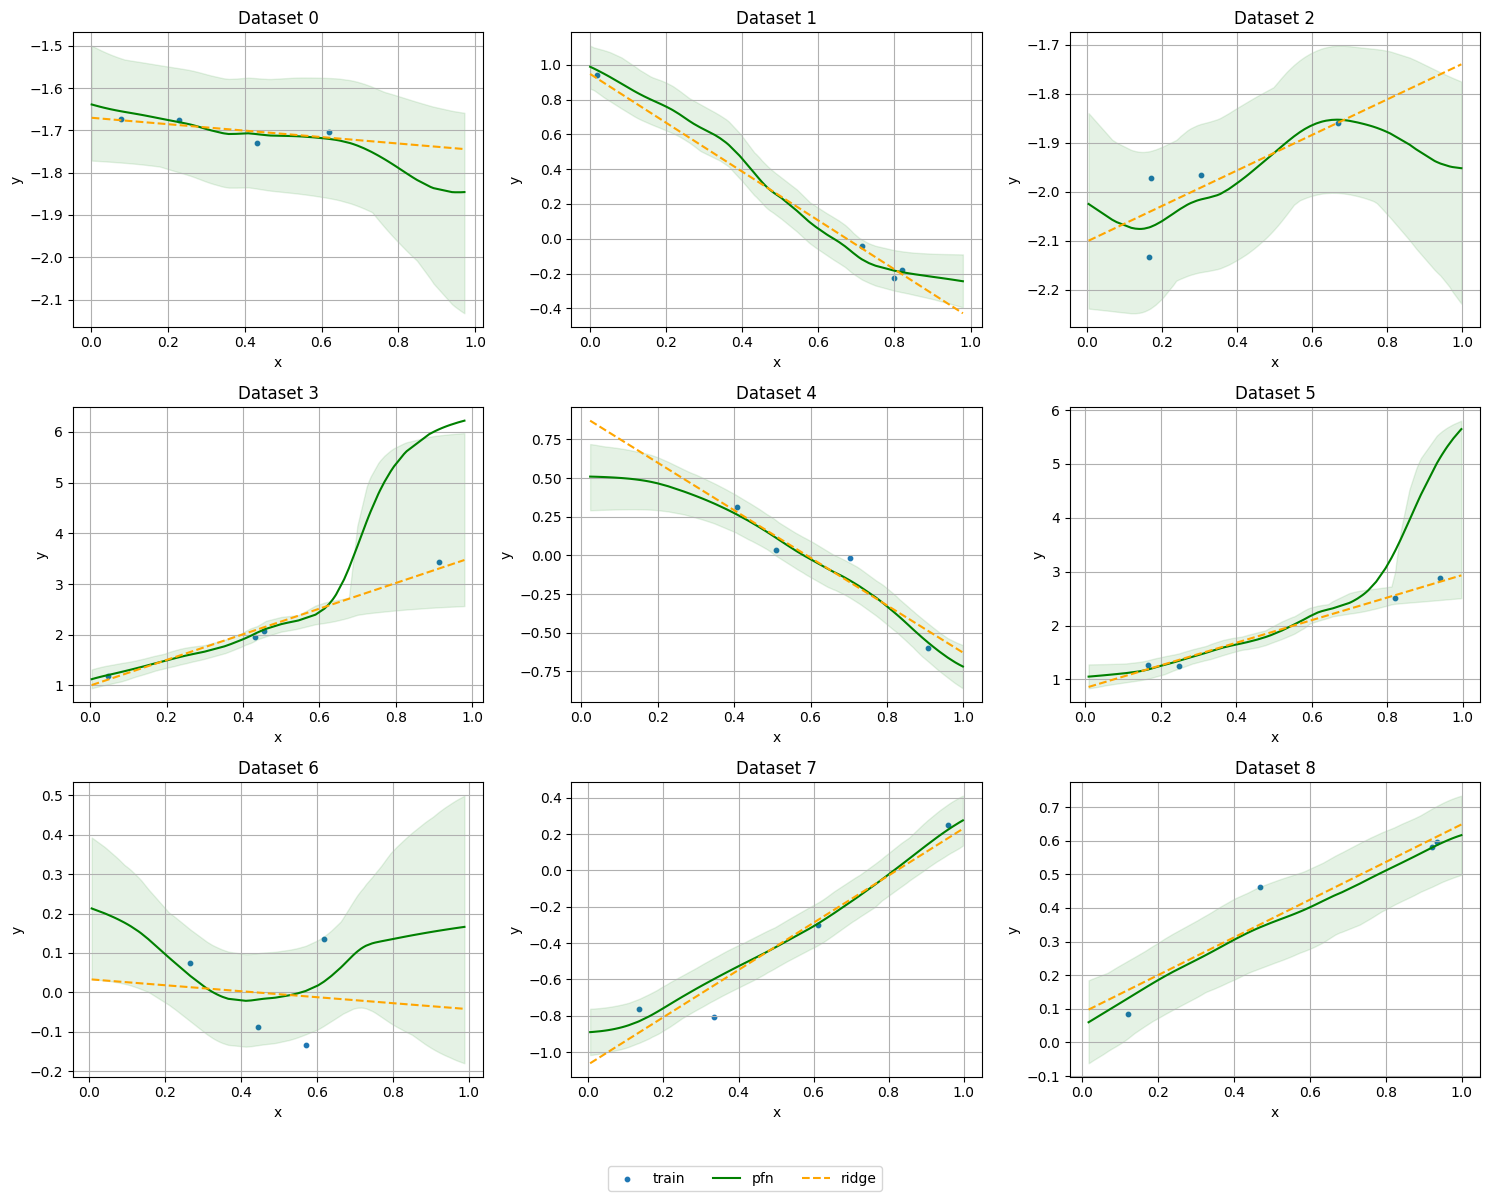

In [13]:
trained_model = trained_model.to('cpu')
criterion = criterion.to("cpu")

import sklearn.linear_model
set_randomness_seed(2402)

batch = get_batch_linear(seq_len=100, batch_size=9, device="cpu")
num_training_points = 4

a = 0.1
b = 1.0
ridge_model = sklearn.linear_model.Ridge(alpha=(a/b)**2)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for batch_index in range(9):
    ax = axes[batch_index]
    train_x = batch['x'][:num_training_points, batch_index]
    train_y = batch['y'][:num_training_points, batch_index]
    test_x  = batch['x'][:, batch_index]

    with torch.no_grad():
        logits = trained_model(train_x[:, None], train_y[:, None], test_x[:, None])
    pred_means = criterion.mean(logits)
    pred_confs = criterion.quantile(logits)

    order_test_x = test_x[..., 0].argsort()
    ax.scatter(train_x[..., 0], train_y, label="train", s=10)
    ax.plot(test_x[order_test_x, ..., 0], pred_means[order_test_x], color='green', label='pfn')
    ax.fill_between(test_x[order_test_x, ..., 0],
                    pred_confs[..., 0, 0][order_test_x],
                    pred_confs[..., 0, 1][order_test_x],
                    alpha=0.1, color='green')
    ridge_model.fit(train_x, train_y)
    ax.plot(test_x[order_test_x].squeeze(), ridge_model.predict(test_x[order_test_x]),
            label='ridge', linestyle='--', color='orange')
    ax.set_title(f"Dataset {batch_index}")
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.grid(True)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


## 4. MLP-SCM Prior

Linear regression is a very simple toy problem; now let's use a **much** more interesting prior that allows our model to actually solve real tabular classification problems.

The prior used by the original TabPFNv2 is built from random **structural causal models (SCMs)**, here we use MLPs in order to sample random graphs for our SCM Prior. The intuition is:

- A small randomly-initialized MLP with random activation functions defines a deterministic causal map.
- We sample inputs ("causes") from a distribution.
- We forward-pass them through the MLP — adding small Gaussian noise after each layer to mimic measurement noise.
- If the `is_causal` hyperparameter is true, then the features `X`  and the label `y` are picked from intermediate-layer activations. Otherwise `X` is the input of the MLP and `y` is the output.
- For classification we then discretize `y` into integer class labels.

Each individual draw (a different MLP, a different sampling distribution, a different noise level…) gives us a *different* synthetic tabular dataset. Training Nano-TabPFN on millions of such datasets teaches it to do in-context learning on tabular data.

In the cells below we build this MLP-SCM prior step by step. Each function has a precise docstring — read carefully, because **this section also contains 3 hidden semantic bugs** in addition to the TODOs.

This Prior implementation is a simplified version of the Prior used by the [TabICL foundation model](https://arxiv.org/pdf/2502.05564).

### 4.1  Sampling causes

In [14]:
import math, random
import numpy as np

def sample_causes(n: int, d: int, method: str, device: str) -> torch.Tensor:
    """
    Sample input "causes" for the MLP-SCM.

    Args:
        n: (int) number of samples (rows) to generate
        d: (int) number of cause variables (columns) to generate
        method: (str) sampling strategy:
            - "normal"  : draws every entry independently from a standard normal N(0, 1)
            - "uniform" : draws every entry independently from U(0, 1)
            - "mixed"   : for each of the d columns independently picks one of several
                          distributions (normal, multinomial, zipf, uniform) at random
        device: torch device string
    Returns:
        (Tensor) shape (n, d), the sampled causes
    """
    if method == "normal":
        # ----- TODO -----
        # Sample n*d values from a standard normal distribution N(0, 1).
        return torch.randn(n, d, device=device)
        # raise NotImplementedError
        # ----------------
    if method == "uniform":
        return torch.rand(n, d, device=device)

    # mixed: choose a random per-column distribution
    cols = []
    zp, mp, np_ = (random.random() * .66 for _ in range(3))
    for _ in range(d):
        r = random.random()
        if r > np_:
            x = torch.randn(n, device=device)
        elif r > mp:
            x = torch.multinomial(torch.rand(random.randint(2, 20), device=device), n, replacement=True).float()
            s = x.std()
            x = (x - x.mean()) / (s if s > 0 else 1.)
        elif r > zp:
            x = torch.tensor(np.random.zipf(2 + random.random() * 2, (n,)),
                             device=device, dtype=torch.float).clamp(max=10)
            x = x - x.mean()
        else:
            x = torch.rand(n, device=device)
        cols.append(x)
    return torch.stack(cols, -1)


### 4.2  Random activations

In [15]:
class _Fn(nn.Module):
    def __init__(self, fn): super().__init__(); self.fn = fn
    def forward(self, x): return self.fn(x)

ACTS = [nn.Tanh, nn.ReLU, nn.LeakyReLU, nn.ELU, nn.SELU, nn.SiLU, nn.Softplus, nn.Identity,
        lambda: _Fn(lambda x: torch.exp(-(x**2))),
        lambda: _Fn(lambda x: 2 * (x >= 0).float() - 1),
        lambda: _Fn(torch.sin),
        lambda: _Fn(lambda x: x ** 2),
        lambda: _Fn(lambda x: torch.sqrt(torch.abs(x)))]


### 4.3  Building and running the random MLP-SCM

In [16]:
@torch.no_grad()
def generate_scm(seq_len: int, nf: int, *,
                 is_causal: bool, num_causes: int, y_is_effect: bool, in_clique: bool,
                 sort_features: bool, num_layers: int, hidden_dim: int, init_std: float,
                 block_wise_dropout: bool, dropout_prob: float,
                 sampling: str, noise_std: float, device: str):
    """
    Build a random MLP-SCM and run it once on sampled causes to produce one (X, y) regression dataset.

    Two operating modes (selected by `is_causal`):
      • is_causal=True  : input width is `num_causes` (small, ~1..12). After the forward pass
                          we treat the concatenation of every layer's activations as a pool and
                          read X (nf columns) and y (1 column) from a random permutation of that
                          pool. y is the final-layer activation if `y_is_effect`, else a random
                          column from the permutation. If `in_clique` we draw X and y from a
                          contiguous block (so they're structurally tightly related); if
                          `sort_features` we keep X's columns in the original order.
      • is_causal=False : input width is `nf`. We append an extra (act -> Linear) block that
                          outputs 1 dim, take X = the original causes and y = that final 1-dim
                          activation directly.

    Weight initialization (toggled by `block_wise_dropout`):
      • False : per-element sparse normal — N(0, init_std/√(1-dp)) with element-wise Bernoulli
                masking at keep prob (1-dropout_prob).
      • True  : block-sparse — split each weight matrix into `nb` blocks; init each block with
                a normal scaled by 1/√(keep_fraction); zero everything outside the blocks.

    The forward pass adds N(0, noise_std) noise after each layer (this is the TODO).

    Args:
        seq_len: (int) number of rows
        nf: (int) number of features in the returned X
        is_causal: (bool) see modes above
        num_causes: (int) input dim when is_causal=True
        y_is_effect: (bool) when is_causal=True, take y from the last layer if True
        in_clique: (bool) when is_causal=True, draw X and y from a contiguous block
        sort_features: (bool) when is_causal=True, keep X columns in the original order
        num_layers: (int) number of MLP layers (>=2)
        hidden_dim: (int) hidden width
        init_std: (float) std for normal init of weights
        block_wise_dropout: (bool) toggles the init scheme (see above)
        dropout_prob: (float) per-weight dropout probability for sparsity
        sampling: (str) cause sampling method (see `sample_causes`)
        noise_std: (float) std of the Gaussian noise added after each layer
        device: torch device
    Returns:
        X: (Tensor) shape (seq_len, nf)
        y: (Tensor) shape (seq_len,)
    """
    dropout_prob = min(dropout_prob, .99)
    num_layers = max(num_layers, 2)
    act_factory = random.choice(ACTS)

    if is_causal:
        hdim = max(hidden_dim, 1 + 2 * nf)
        nc = num_causes
    else:
        hdim, nc = hidden_dim, nf

    def block(out_dim):
        a = act_factory() if not isinstance(act_factory, type) else act_factory()
        return nn.Sequential(a, nn.Linear(hdim, out_dim))

    layers = [nn.Linear(nc, hdim)]
    for _ in range(num_layers - 1):
        layers.append(block(hdim))
    if not is_causal:
        layers.append(block(1))
    net = nn.Sequential(*layers).to(device)

    # Init weights — element-wise sparse normal, OR block-wise sparse normal
    for idx, (_, p) in enumerate(net.named_parameters()):
        if p.dim() != 2:
            continue
        if block_wise_dropout:
            nn.init.zeros_(p)
            nb = random.randint(1, math.ceil(math.sqrt(min(p.shape))))
            bs = [d // nb for d in p.shape]
            keep = (nb * bs[0] * bs[1]) / p.numel()
            for b in range(nb):
                sl = tuple(slice(d * b, d * (b + 1)) for d in bs)
                nn.init.normal_(p[sl], std=init_std / keep ** .5)
        else:
            dp = dropout_prob if idx > 0 else 0.
            nn.init.normal_(p, std=init_std / (1 - dp) ** .5)
            p.data *= torch.bernoulli(torch.full_like(p, 1 - dp))

    # ----- TODO -----
    # Forward pass: run `causes` through `net`, adding N(0, noise_std) noise after EACH layer.
    # Save the output of every layer in `outs` (with `causes` as the first entry).
    # raise NotImplementedError
    causes = sample_causes(seq_len, nc, sampling, device)
    outs = [causes]
    temp = outs[0]
    for layer in net:
        temp = layer(temp)
        temp = temp + torch.randn_like(temp) * noise_std
        outs.append(temp)
    # ----------------
    outs = outs[2:]  # discard causes and first bare linear

    if is_causal:
        flat = torch.cat(outs, -1)
        D = flat.shape[-1]
        if in_clique:
            s = random.randint(0, D - 1 - nf)
            perm = s + torch.randperm(1 + nf, device=device)
        else:
            perm = torch.randperm(D - 1, device=device)
        ix = perm[1:1 + nf]
        iy = list(range(-1, 0)) if y_is_effect else perm[:1]
        if sort_features:
            ix, _ = torch.sort(ix)
        X, y = flat[:, ix], flat[:, iy]
    else:
        X, y = causes, outs[-1]

    if not (torch.isfinite(X).all() and torch.isfinite(y).all()):
        return torch.zeros(seq_len, nf, device=device), torch.full((seq_len,), -100., device=device)
    return X, y.squeeze(-1)

### 4.4  Standardization, label discretization, and post-processing

In [17]:
# BUG! it's a chance to improve!
def zscale(x: torch.Tensor, clip: float = 100.) -> torch.Tensor:
    """
    Standardize each column of `x` independently: subtract that column's mean,
    divide by that column's std (with a tiny floor to avoid division by zero).
    The result is then clipped to [-clip, clip] to handle outliers.

    Per-column statistics (axis=0) are essential — using a single global mean/std
    would mix information across features and ignore per-column scale.

    Args:
        x: (Tensor) shape (n, d)
        clip: (float) absolute value clip after standardization
    Returns:
        (Tensor) same shape as `x`
    """
    return ((x - x.mean(dim=0, keepdim=True)) / x.std(dim=0, keepdim=True).clamp(min=1e-6)) #was global mean and std


In [18]:
def permute_classes(y: torch.Tensor) -> torch.Tensor:
    """Randomly relabel classes so the model can't rely on label ordering."""
    u = torch.unique(y); nc = len(u)
    if nc <= 1: return y
    return torch.randperm(nc, device=y.device)[u.argsort()[torch.searchsorted(u, y)]]


def assign_classes(y: torch.Tensor, nc: int) -> torch.Tensor:
    """
    Discretize a continuous regression target `y` into `nc` integer class labels.

    Strategy:
      1. Pick `nc - 1` thresholds. With probability 0.5 these thresholds are sampled
         (with replacement) from the empirical values of `y` itself; with probability 0.5
         they are sampled from a standard normal N(0, 1). This mixed strategy keeps the
         resulting class boundaries diverse.
      2. For each entry of `y`, count how many thresholds it strictly EXCEEDS — that count
         is the integer class label in [0, nc).
      3. Optionally permute / reverse the class labels so the labels carry no ordinal info.

    Args:
        y: (Tensor) shape (n,), continuous targets
        nc: (int) number of classes
    Returns:
        (Tensor) shape (n,), integer class labels in [0, nc)
    """
    # ----- TODO -----
    # 1. Sample nc-1 thresholds `b`, picking with prob 0.5 from y itself, else from N(0,1).
    # 2. For each y_i count how many of the thresholds in b are strictly less than y_i.
    # raise NotImplementedError
    
    if random.random() > 0.5:
        b = y[torch.randint(0, len(y), (nc - 1,))]
    else:
        b = torch.randn(nc - 1, device=y.device)
    # ----------------
    c = (y.unsqueeze(-1) > b.unsqueeze(0)).sum(1)
    if random.random() > .2: c = permute_classes(c)
    if random.random() > .5: c = nc - 1 - c
    return c


In [19]:
# This process seems BUGgy!
def process(X: torch.Tensor, y: torch.Tensor, nc: int, maxf: int):
    """
    Post-process raw (X, y) from the SCM into the final tensors that go into a batch.

    Steps, in order:
        1. Standardize features X using `zscale`.
        2. Randomly permute X's columns so feature order is meaningless.
        3. Pad X with zero-columns to reach width `maxf`. (Padding has to come AFTER the
           permutation, otherwise zero pads get shuffled into the active feature region.)
        4. Standardize y, discretize into `nc` classes via `assign_classes`, and permute labels.

    Args:
        X: (Tensor) shape (n, d_active)
        y: (Tensor) shape (n,)
        nc: (int) number of classes
        maxf: (int) target feature width (must be >= d_active)
    Returns:
        X: (Tensor) shape (n, maxf)
        y: (Tensor) shape (n,)  (integer class labels stored as float)
    """
    X = zscale(X)
    X = X[:, torch.randperm(X.shape[1], device=X.device)]   #permute must happen before padding
    if X.shape[1] < maxf:
        X = F.pad(X, (0, maxf - X.shape[1]))
    y = assign_classes(zscale(y.unsqueeze(-1)).squeeze(-1), nc)
    return X.float(), permute_classes(y).float()


### 4.5  Quality checks on the generated dataset

In [20]:
# The last BUG you need to fix!
def drop_const(X: torch.Tensor, d: int):
    """
    Drop constant columns from the active feature region of `X`.

    A constant column has the same value across all rows (no variation), so it carries no
    information. We drop them and re-pad with zeros so the total feature width stays the same.

    Args:
        X: (Tensor) shape (n, maxf), where the first `d` columns are the active features
        d: (int) number of active feature columns
    Returns:
        X: (Tensor) shape (n, maxf), with constant active columns removed and re-padded
        d2: (int) number of remaining active columns (0 if all were constant)
    """
    active = X[:, :d]
    keep = torch.tensor([active[:, j].unique().numel() > 1 for j in range(d)], device=X.device)
    d2 = int(keep.sum())
    return (F.pad(active[:, keep], (0, X.shape[1] - d2)), d2) if d2 else (X, 0)


def valid_split(y: torch.Tensor, ts: int) -> bool:
    """
    Check that splitting `y` at index `ts` produces a valid train/test classification split.

    Both conditions must hold:
        - The set of class labels in y[:ts] is exactly equal to the set in y[ts:].
          (We never want a class to appear at test time that the model has never seen
          at training time, and we also don't want training-only classes that vanish at test.)
        - The training portion contains at least 2 distinct classes.

    Args:
        y: (Tensor) shape (n,), labels
        ts: (int) train-set size; the split is y[:ts] vs y[ts:]
    Returns:
        (bool) whether the split satisfies BOTH conditions
    """
    if ts <= 0 or ts >= len(y): return False
    tr, te = set(y[:ts].unique().tolist()), set(y[ts:].unique().tolist())
    return tr == te and len(tr) >= 2    #incorrect check


### 4.6  The `MLPPrior` class and its DataLoader wrapper

The code below is still quite complex and not yet simplified, so we did not introduce any bug here!

In [21]:
class MLPPrior:
    """
    Lightweight MLP-SCM prior. `get_batch()` returns one batch of synthetic
    classification datasets in the format expected by Nano-TabPFN's training loop.
    """

    def __init__(self, batch_size: int = 64,
                 min_features: int = 2, max_features: int = 20,
                 max_classes: int = 10,
                 min_seq_len: int = None, max_seq_len: int = 1024,
                 min_train_ratio: float = .1, max_train_ratio: float = .9,
                 device: str = "cpu"):
        self.batch_size, self.device = batch_size, device
        self.min_features, self.max_features = min_features, max_features
        self.max_classes = max_classes
        self.min_seq_len, self.max_seq_len = min_seq_len, max_seq_len
        self.min_train_ratio, self.max_train_ratio = min_train_ratio, max_train_ratio

    @staticmethod
    def _hp() -> dict:
        """Sample one random hyperparameter configuration for an SCM (full diversity)."""
        R, U = random.choice, random.randint
        return dict(
            is_causal=R([True, False]),
            num_causes=U(1, 12),
            y_is_effect=R([True, False]),
            in_clique=R([True, False]),
            sort_features=R([True, False]),
            num_layers=U(2, 8),
            hidden_dim=U(4, 130),
            init_std=float(np.exp(np.random.uniform(np.log(.01), np.log(10.)))),
            block_wise_dropout=R([True, False]),
            dropout_prob=float(np.random.beta(.5, 2.) * .9),
            sampling=R(["normal", "mixed", "uniform"]),
            noise_std=float(np.exp(np.random.uniform(np.log(1e-4), np.log(.3)))),
        )

    @torch.no_grad()
    def _gen(self, sl: int, ts: int, nf: int, nc: int):
        """Generate one synthetic dataset (X, y, d). `d` is the number of active features."""
        for _ in range(50):
            X, y = generate_scm(sl, nf, device=self.device, **self._hp())
            X, y = process(X, y, nc, self.max_features)
            X, d = drop_const(X, nf)
            if d == 0: continue
            if valid_split(y, ts): return X, y, d
            for _ in range(10):
                p = torch.randperm(sl, device=self.device)
                if valid_split(y[p], ts): return X[p], y[p], d
        return (torch.randn(sl, self.max_features, device=self.device),
                torch.randint(0, 2, (sl,), device=self.device).float(),
                self.max_features)

    @torch.no_grad()
    def get_batch(self, batch_size=None):
        B = batch_size or self.batch_size
        sl = random.randint(self.min_seq_len, self.max_seq_len) if self.min_seq_len else self.max_seq_len
        ts = max(1, min(int(sl * random.uniform(self.min_train_ratio, self.max_train_ratio)), sl-1))
        Xs, ys, ds = zip(*[self._gen(sl, ts, random.randint(self.min_features, self.max_features),
                                     random.randint(2, self.max_classes) if random.random()>.5 else 2)
                           for _ in range(B)])
        return (torch.stack(Xs), torch.stack(ys),
                torch.tensor(ds, device=self.device, dtype=torch.long),
                torch.full((B,), sl, device=self.device, dtype=torch.long),
                torch.full((B,), ts, device=self.device, dtype=torch.long))

In [22]:
class MLPPriorDataLoader:
    """DataLoader that generates synthetic data on the fly via MLPPrior."""

    def __init__(self, num_steps, batch_size, max_features=5, max_seq_len=150,
                 max_classes=2, device=None):
        self.num_steps = num_steps
        self.device = device or get_default_device()
        self.prior = MLPPrior(
             batch_size=batch_size,
             max_features=max_features,
             max_seq_len=max_seq_len, # max_seq_len=max_seq_len,
             max_classes=max_classes,
             device="cpu",  # generate on CPU, move in tabicl_to_ours
        )

    def tabicl_to_ours(self, d):
        x, y, active_features, seqlen, train_size = d
        active_features = active_features[0].item()
        x = x[:, :, :active_features]
        single_eval_pos = train_size[0].item()
        x = x.transpose(0, 1)
        y = y.transpose(0, 1)
        return dict(
            x=x.to(self.device),
            y=y.to(self.device),
            single_eval_pos=single_eval_pos,
        )

    def __iter__(self):
        for _ in range(self.num_steps):
            #yield next(self.prior)
            yield self.tabicl_to_ours(self.prior.get_batch())

    def __len__(self):
        return self.num_steps


### 4.7  Train Nano-TabPFN on the MLP-SCM prior

We now train classification on synthetic datasets generated on-the-fly by the MLP-SCM prior.
Compared to the original notebook this is a meaningful change: instead of loading 100k pre-generated datasets from disk, every batch is freshly synthesized.

You can play around with `batch_size`, `num_steps`, `epochs`, `max_features`, `max_seq_len`, etc. The settings below are kept small so the cell finishes in a few minutes on CPU. Larger settings give a stronger model.

In [23]:
set_randomness_seed(0)
device = get_default_device()

model = NanoTabPFNModel(
    embedding_size=96, num_attention_heads=4,
    mlp_hidden_size=192, num_layers=3, num_outputs=2,
)

prior = MLPPriorDataLoader(
    num_steps=2500, batch_size=32, max_features=5, 
    max_seq_len=150, max_classes=2, device=device,
)

model, history = train(
    model, prior, criterion=nn.CrossEntropyLoss(), epochs=1,
    lr=4e-3, device=device, steps_per_log=100,
)




step   100 | epoch   1 | time    17.9s | loss(last 100)  0.5690
step   200 | epoch   1 | time    35.6s | loss(last 100)  0.4856
step   300 | epoch   1 | time    50.9s | loss(last 100)  0.4709
step   400 | epoch   1 | time    67.8s | loss(last 100)  0.4462
step   500 | epoch   1 | time    85.0s | loss(last 100)  0.4548
step   600 | epoch   1 | time   101.4s | loss(last 100)  0.4372
step   700 | epoch   1 | time   117.0s | loss(last 100)  0.4441
step   800 | epoch   1 | time   131.7s | loss(last 100)  0.4552
step   900 | epoch   1 | time   146.4s | loss(last 100)  0.4477
step  1000 | epoch   1 | time   161.1s | loss(last 100)  0.4522
step  1100 | epoch   1 | time   176.5s | loss(last 100)  0.4422
step  1200 | epoch   1 | time   212.1s | loss(last 100)  0.4488
step  1300 | epoch   1 | time   227.8s | loss(last 100)  0.4582
step  1400 | epoch   1 | time   242.5s | loss(last 100)  0.4447
step  1500 | epoch   1 | time   257.4s | loss(last 100)  0.4480
step  1600 | epoch   1 | time   272.4s |

## 5. Comparison vs scikit-learn baselines

We now have a Nano-TabPFN trained on the MLP-SCM prior. Let's compare it against scikit-learn baselines and the official TabPFN v2.

First, the sklearn-style wrapper.

In [24]:
class NanoTabPFNClassifier:
    """ scikit-learn-like interface around our trained Nano-TabPFN. """
    def __init__(self, model, device=get_default_device()):
        """ Move the model to the correct device. """
        self.model = model.to(device)
        self.device = device

    def fit(self, X_train, y_train):
        """ Stash the training data and remember how many distinct classes we saw. """
        self.X_train = X_train
        self.y_train = y_train
        self.num_classes = len(set(y_train))

    def predict(self, X_test):
        """ Calls predict_proba and picks the most-probable class for each datapoint. """
        predicted_probabilities = self.predict_proba(X_test)
        return np.argmax(predicted_probabilities, axis=1)
        # ----- TODO -----
        # raise NotImplementedError
        # ----------------

    def predict_proba(self, X_test):
        """
        Build the (x, y) tensors, run the model, restrict the logits to the classes
        actually seen in training, and apply softmax to obtain class probabilities.
        """
        x = np.concatenate((self.X_train, X_test))
        y = self.y_train
        with torch.no_grad():
            x = torch.from_numpy(x).unsqueeze(1).to(torch.float).to(self.device)
            y = torch.from_numpy(y).unsqueeze(1).to(torch.float).to(self.device)
            out = self.model((x, y), single_eval_pos=len(self.X_train)).squeeze(1)
            # ----- TODO -----
            # Our pretrained classifier may support more classes than the current problem;
            # only keep the first self.num_classes logits, then softmax over them.

            # raise NotImplementedError
            out = out[:, :self.num_classes]
            probabilities = torch.softmax(out, dim=-1)
            # ----------------
            return probabilities.to('cpu').numpy()


Now we compare TabPFN v2 against SVM, Logistic Regression, RandomForest and Nano-TabPFN on three small toy 2D classification tasks. (This may take a few minutes.)

3it [05:17, 105.90s/it]


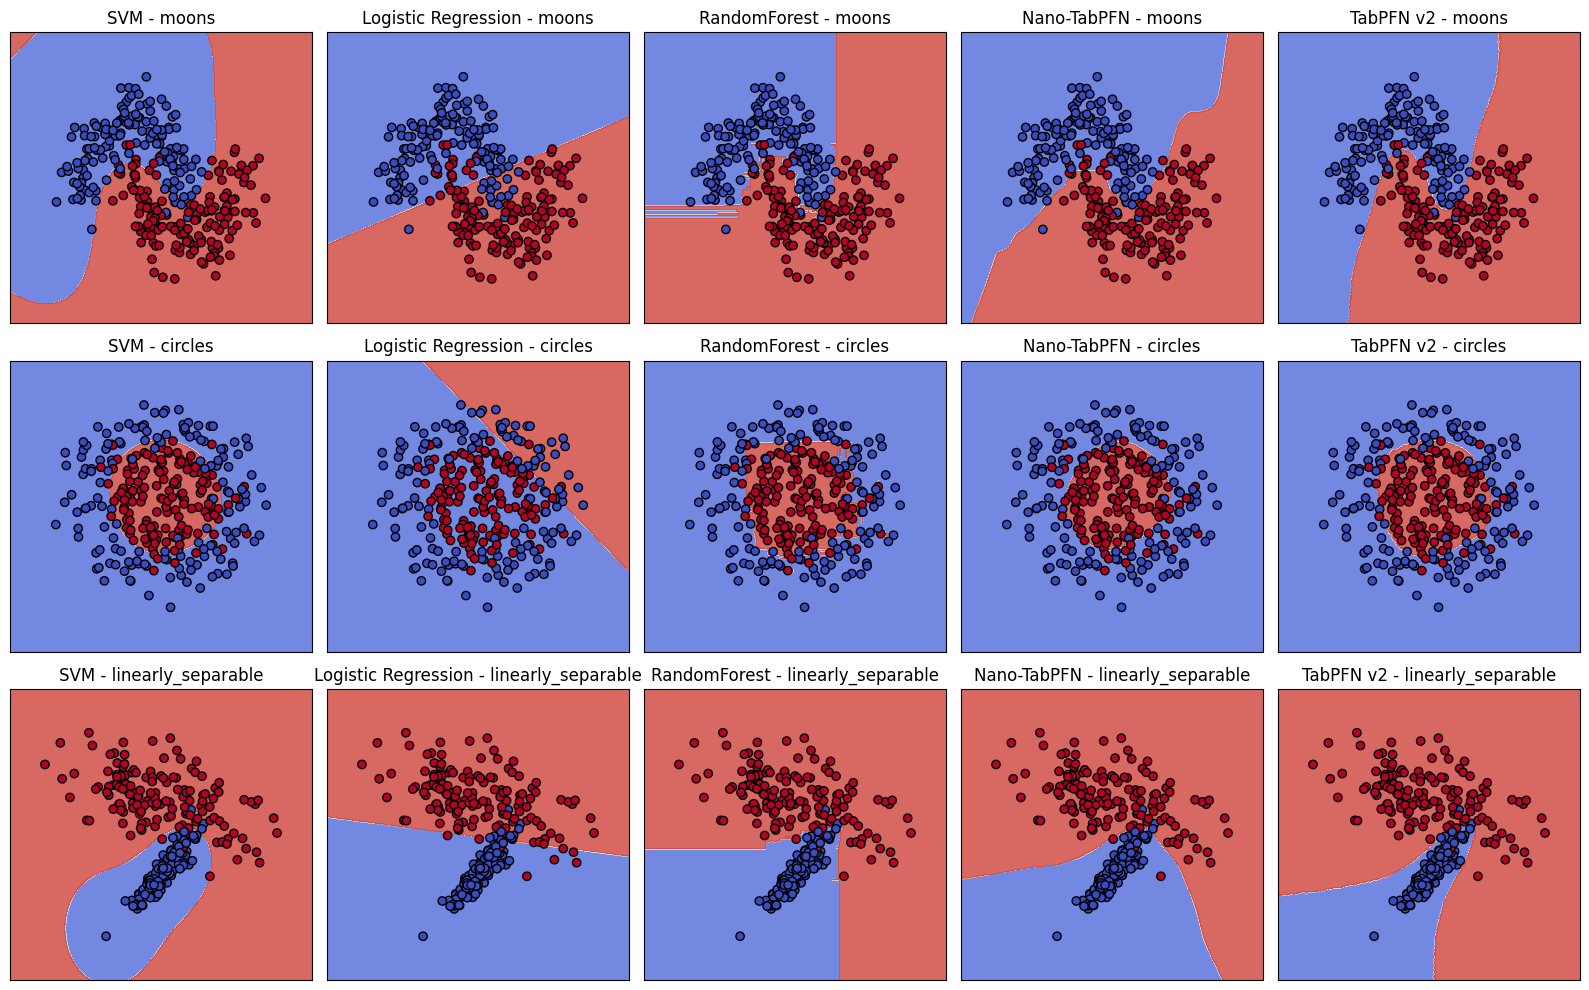

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tabpfn import TabPFNClassifier
from tqdm import tqdm
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")
set_randomness_seed(2402)

datasets = {
    "moons": make_moons(n_samples=300, noise=0.2, random_state=42),
    "circles": make_circles(n_samples=300, noise=0.2, factor=0.5, random_state=42),
    "linearly_separable": make_classification(n_samples=300, n_features=2, n_redundant=0,
                                               n_informative=2, random_state=42,
                                               n_clusters_per_class=1)
}

models = {
    # ----- TODO -----
    "SVM": SVC(),
    "Logistic Regression": LogisticRegression(),
    "RandomForest": RandomForestClassifier(),
    # ----------------
    "Nano-TabPFN": NanoTabPFNClassifier(model.to('cpu'), device='cpu'),
    "TabPFN v2": TabPFNClassifier(device='cpu'),
}

def plot_decision_boundary(ax, clf, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    ax.set_title(title); ax.set_xticks(()); ax.set_yticks(())

fig, axes = plt.subplots(len(datasets), len(models), figsize=(16, 10))
for row_idx, (ds_name, (X, y)) in tqdm(enumerate(datasets.items())):
    X = StandardScaler().fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    for col_idx, (model_name, clf) in enumerate(models.items()):
        ax = axes[row_idx, col_idx]
        if model_name == "TabPFN v2":
            clf.fit(X_train.astype(np.float32), y_train)
        else:
            clf.fit(X_train, y_train)
        plot_decision_boundary(ax, clf, X, y, f"{model_name} - {ds_name}")

plt.tight_layout()
plt.show()


Compare the official TabPFN implementation to SVM, Logistic Regression, RandomForest and Nano-TabPFN. Mention at least one similarity or difference to each model. Please put your answer in the cell below.

(4 points)
TODO

SVM
Both produce smooth decision boundaries and work well on small datasets. Unlike SVM, TabPFN v2 needs no kernel choice or hyperparameter tuning.


Logistic Regression
Both output class probabilities and are fast at inference. Unlike Logistic Regression, TabPFN v2 doesnt need feature engineering for non linear boundaries.


Random Forest
Both handle non-linearity well without manual feature engineering. Unlike Random Forest, TabPFN v2 produces smoother boundaries and requires no fitting at test time.


Nano-TabPFN
Both use the same in-context learning mechanism — a transformer doing fitting and inference in one forward pass. TabPFN v2 produces significantly better boundaries due to larger scale training and a richer prior.

## LLM Usage & Optional Feedback

Please describe the way you used LLMs to solve this exercise in the cell below. If you would like to leave any feedback about how you liked this exercise you can leave it in the cell below as well.

(LLM Usage) (optional feedback)

In [26]:
# Used LLM to understand the topics given in the notebook.
# Used LLMS to understand syntax of libraries used in the notebook.
